<a href="https://colab.research.google.com/github/yasminsyamlann-xd/modul-1/blob/main/MODUL_5_MESIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.4 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gymnasium as gym

# Membuat environment CartPole
env = gym.make("CartPole-v1")

# Melihat ukuran state dan action
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)


In [ ]:
from stable_baselines3 import PPO

# Membuat model PPO
model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)

# Training
model.learn(total_timesteps=10000)

print("Training selesai")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.2     |
|    ep_rew_mean     | 22.2     |
| time/              |          |
|    fps             | 1235     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.4        |
|    ep_rew_mean          | 25.4        |
| time/                   |             |
|    fps                  | 911         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008905241 |
|    clip_fraction        | 0.127       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.685      |
|    explained_variance   | 0.00123     |
|    learning_rate        | 0.0003      |
|    loss                 | 7.3         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0212     |
|    value_loss           | 55          |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 34.6  

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

from stable_baselines3 import PPO

In [ ]:
class Robot1DEnv(gym.Env):

    def __init__(self, goal=8.0, max_steps=100):

        super().__init__()

        self.goal = goal
        self.max_steps = max_steps

        # Action:
        # 0 = bergerak kiri
        # 1 = bergerak kanan
        self.action_space = spaces.Discrete(2)

        # Observation:
        # posisi robot dan posisi tujuan
        self.observation_space = spaces.Box(
            low=np.array([-10, -10], dtype=np.float32),
            high=np.array([10, 10], dtype=np.float32)
        )


    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.position = 0.0
        self.steps = 0

        return self._get_obs(), {}


    def step(self, action):

        # pergerakan robot
        if action == 1:
            self.position += 1.0
        else:
            self.position -= 1.0


        self.steps += 1


        # menghitung jarak ke tujuan
        distance = abs(self.position - self.goal)


        # reward
        reward = -distance * 0.1


        # jika sampai tujuan
        terminated = distance < 0.5


        # jika langkah terlalu banyak
        truncated = self.steps >= self.max_steps


        if terminated:
            reward += 10


        return (
            self._get_obs(),
            reward,
            terminated,
            truncated,
            {}
        )


    def _get_obs(self):

        return np.array(
            [self.position, self.goal],
            dtype=np.float32
        )

In [ ]:
env = Robot1DEnv(goal=8.0)


obs, info = env.reset()

print("Initial state:", obs)


for i in range(10):

    action = env.action_space.sample()

    obs, reward, done, trunc, info = env.step(action)

    print(
        "Step:",
        i,
        "Position:",
        obs[0],
        "Reward:",
        reward
    )

    if done or trunc:
        break

Initial state: [0. 8.]
Step: 0 Position: -1.0 Reward: -0.9
Step: 1 Position: -2.0 Reward: -1.0
Step: 2 Position: -1.0 Reward: -0.9
Step: 3 Position: 0.0 Reward: -0.8
Step: 4 Position: -1.0 Reward: -0.9
Step: 5 Position: 0.0 Reward: -0.8
Step: 6 Position: 1.0 Reward: -0.7000000000000001
Step: 7 Position: 2.0 Reward: -0.6000000000000001
Step: 8 Position: 1.0 Reward: -0.7000000000000001
Step: 9 Position: 0.0 Reward: -0.8


In [ ]:
env = Robot1DEnv(goal=8.0)


model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)


model.learn(
    total_timesteps=50000
)


print("Training selesai!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 78.8     |
|    ep_rew_mean     | -84.2    |
| time/              |          |
|    fps             | 1058     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 46          |
|    ep_rew_mean          | -31.8       |
| time/                   |             |
|    fps                  | 892         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.020016616 |
|    clip_fraction        | 0.37        |
|    clip_range           | 0.2         |
|    entropy_loss   

In [ ]:
obs, info = env.reset()


total_reward = 0


for step in range(20):

    action, _ = model.predict(
        obs,
        deterministic=True
    )


    obs, reward, done, trunc, info = env.step(action)


    total_reward += reward


    print(
        f"Step {step+1} | Posisi Robot: {obs[0]:.2f} | Reward: {reward:.2f}"
    )


    if done or trunc:
        break


print("\nTotal Reward:", total_reward)

Step 1 | Posisi Robot: 1.00 | Reward: -0.70
Step 2 | Posisi Robot: 2.00 | Reward: -0.60
Step 3 | Posisi Robot: 3.00 | Reward: -0.50
Step 4 | Posisi Robot: 4.00 | Reward: -0.40
Step 5 | Posisi Robot: 5.00 | Reward: -0.30
Step 6 | Posisi Robot: 6.00 | Reward: -0.20
Step 7 | Posisi Robot: 7.00 | Reward: -0.10
Step 8 | Posisi Robot: 8.00 | Reward: 10.00

Total Reward: 7.199999999999999


In [ ]:
model.save("ppo_robot1d")


print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
# =====================================
# LAB 5.3 - Build a Portfolio Agent
# PPO Reinforcement Learning
# =====================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np

from stable_baselines3 import PPO


# =====================================
# 1. Custom Portfolio Environment
# =====================================

class PortfolioEnv(gym.Env):

    def __init__(self):

        super().__init__()

        self.n_assets = 3

        # Action = proporsi investasi 3 aset
        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.n_assets,),
            dtype=np.float32
        )

        # Observation = harga aset
        self.observation_space = spaces.Box(
            low=0,
            high=np.inf,
            shape=(self.n_assets,),
            dtype=np.float32
        )


        self.initial_price = np.array(
            [100,100,100],
            dtype=np.float32
        )


    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.prices = self.initial_price.copy()

        self.steps = 0

        return self.prices, {}



    def step(self, action):

        # normalisasi bobot portfolio
        weights = action / (np.sum(action)+1e-8)


        # simulasi return aset
        returns = np.random.normal(
            0,
            0.02,
            self.n_assets
        )


        # update harga
        self.prices *= (1 + returns)


        # reward berdasarkan keuntungan portfolio
        reward = np.dot(
            weights,
            returns
        )


        self.steps += 1


        terminated = self.steps >= 100


        return (
            self.prices,
            reward,
            terminated,
            False,
            {}
        )



# =====================================
# 2. Membuat Environment
# =====================================

env = PortfolioEnv()



# =====================================
# 3. Training PPO Agent
# =====================================

model = PPO(
    "MlpPolicy",
    env,
    verbose=1
)


model.learn(
    total_timesteps=20000
)


print("Training Portfolio selesai!")



# =====================================
# 4. Testing Agent
# =====================================

obs, info = env.reset()


total_reward = 0


for step in range(100):

    action, _ = model.predict(
        obs,
        deterministic=True
    )


    obs, reward, done, trunc, info = env.step(action)


    total_reward += reward


    if done:
        break



print("Total Reward Portfolio:", total_reward)



# =====================================
# 5. Save Model
# =====================================

model.save("ppo_portfolio_agent")


print("Model Portfolio berhasil disimpan!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | 0.0308   |
| time/              |          |
|    fps             | 1471     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 100          |
|    ep_rew_mean          | 0.0425       |
| time/                   |              |
|    fps                  | 1041         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0039869496 |
|    clip_fraction        | 0.0437       |
|    clip_range           | 0.2          |
|    en

In [ ]:
!pip install torchrl tensordict gymnasium[classic-control] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.7 MB/s eta 0:00:00


Torch Version : 2.11.0+cpu
State size : 4
Action size : 2
PolicyNetwork(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
    (5): Softmax(dim=-1)
  )
)
Episode 10, Reward = 19.0
Episode 20, Reward = 40.0
Episode 30, Reward = 51.0
Episode 40, Reward = 12.0
Episode 50, Reward = 14.0
Episode 60, Reward = 119.0
Episode 70, Reward = 20.0
Episode 80, Reward = 44.0
Episode 90, Reward = 24.0
Episode 100, Reward = 172.0

Training selesai
Reward evaluasi : 98.0


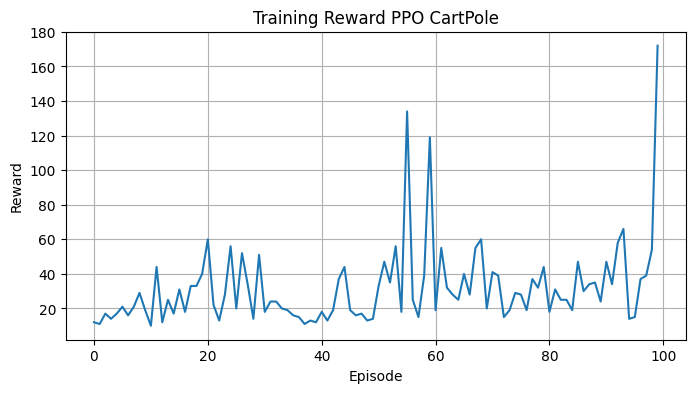

Model berhasil disimpan


In [ ]:
# ============================================
# LAB 5.4 - TORCHRL INTRODUCTION
# Reinforcement Learning with PPO
# ============================================

# Install library
!pip install torchrl tensordict gymnasium[classic-control] -q


# ==========================
# Import Library
# ==========================

import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np

from torch.distributions import Categorical


print("Torch Version :", torch.__version__)


# ==========================
# Membuat Environment
# ==========================

env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n


print("State size :", state_size)
print("Action size :", action_size)



# ==========================
# Membuat Policy Network
# ==========================

class PolicyNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(state_size,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,action_size),
            nn.Softmax(dim=-1)
        )


    def forward(self,state):

        return self.model(state)



policy = PolicyNetwork()

optimizer = optim.Adam(
    policy.parameters(),
    lr=0.001
)


print(policy)



# ==========================
# Fungsi memilih aksi
# ==========================

def choose_action(state):

    state = torch.FloatTensor(state)

    probabilities = policy(state)

    distribution = Categorical(probabilities)

    action = distribution.sample()

    return (
        action.item(),
        distribution.log_prob(action)
    )



# ==========================
# Training PPO sederhana
# ==========================

episodes = 100

reward_history = []


for episode in range(episodes):

    state, info = env.reset()

    done = False

    log_probs = []
    rewards = []


    while not done:

        action, log_prob = choose_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated


        log_probs.append(log_prob)

        rewards.append(reward)


        state = next_state



    # Menghitung return
    returns = []

    G = 0

    for reward in reversed(rewards):

        G = reward + 0.99 * G

        returns.insert(0,G)


    returns = torch.tensor(returns)


    loss = 0


    for log_prob, G in zip(log_probs, returns):

        loss += -log_prob * G



    optimizer.zero_grad()

    loss.backward()

    optimizer.step()



    total_reward = sum(rewards)

    reward_history.append(total_reward)


    if (episode+1)%10==0:

        print(
            f"Episode {episode+1}, Reward = {total_reward}"
        )



env.close()



# ==========================
# Evaluasi Model
# ==========================

env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)


state,info = env.reset()

total_reward = 0

done=False


while not done:

    state_tensor = torch.FloatTensor(state)

    with torch.no_grad():

        action = torch.argmax(
            policy(state_tensor)
        ).item()


    state,reward,terminated,truncated,info = env.step(action)

    total_reward += reward

    done = terminated or truncated



env.close()


print("\n==============================")
print("Training selesai")
print("Reward evaluasi :", total_reward)
print("==============================")



# ==========================
# Grafik Reward
# ==========================

import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))

plt.plot(reward_history)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.title("Training Reward PPO CartPole")

plt.grid()

plt.show()



# ==========================
# Simpan Model
# ==========================

torch.save(
    policy.state_dict(),
    "torchrl_cartpole_policy.pth"
)


print("Model berhasil disimpan")

Drone Environment berhasil dibuat
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 97       |
|    ep_rew_mean     | -72      |
| time/              |          |
|    fps             | 1320     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 97.9        |
|    ep_rew_mean          | -66.5       |
| time/                   |             |
|    fps                  | 933         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.017428458 |
|    clip_fraction        | 0.232       |
|    clip_range           | 

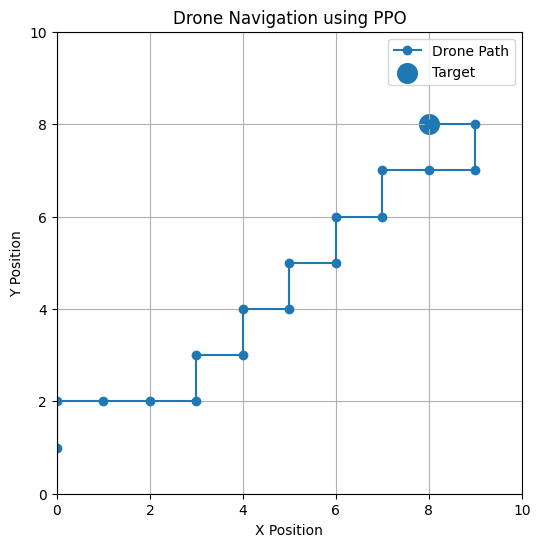

Model Drone berhasil disimpan


In [ ]:
# =====================================================
# LAB 5.6 - DRONE REINFORCEMENT LEARNING
# PPO Agent for Simple Drone Navigation
# =====================================================


# Install library
!pip install stable-baselines3 gymnasium -q


# ==========================
# Import Library
# ==========================

import gymnasium as gym
from gymnasium import spaces

import numpy as np

import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback



# ==========================
# Drone Environment
# ==========================

class DroneEnv(gym.Env):

    def __init__(self):

        super().__init__()


        # Action:
        # 0 = up
        # 1 = down
        # 2 = left
        # 3 = right

        self.action_space = spaces.Discrete(4)


        # State:
        # drone x,y
        # target x,y

        self.observation_space = spaces.Box(
            low=0,
            high=10,
            shape=(4,),
            dtype=np.float32
        )


        self.max_steps = 100


    def reset(self, seed=None, options=None):

        super().reset(seed=seed)


        self.drone = np.array(
            [0.0,0.0],
            dtype=np.float32
        )


        self.target = np.array(
            [8.0,8.0],
            dtype=np.float32
        )


        self.steps = 0


        state = np.concatenate(
            [
                self.drone,
                self.target
            ]
        )


        return state, {}



    def step(self,action):

        self.steps += 1


        # Movement drone

        if action == 0:
            self.drone[1] += 1

        elif action == 1:
            self.drone[1] -= 1

        elif action == 2:
            self.drone[0] -= 1

        elif action == 3:
            self.drone[0] += 1



        # batas area

        self.drone = np.clip(
            self.drone,
            0,
            10
        )


        # jarak drone ke target

        distance = np.linalg.norm(
            self.drone-self.target
        )


        # reward

        reward = -distance/10


        terminated = False



        # jika sampai target

        if distance < 1:

            reward = 10

            terminated = True



        if self.steps >= self.max_steps:

            terminated = True



        state = np.concatenate(
            [
                self.drone,
                self.target
            ]
        )


        return (
            state,
            reward,
            terminated,
            False,
            {}
        )



# ==========================
# Membuat Environment
# ==========================


env = DroneEnv()


print("Drone Environment berhasil dibuat")



# ==========================
# Training PPO Agent
# ==========================


model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.001
)



model.learn(
    total_timesteps=20000
)


print("Training Drone selesai")



# ==========================
# Evaluasi Drone
# ==========================


state,info = env.reset()


done=False

total_reward=0


path=[]


while not done:


    action,_ = model.predict(
        state
    )


    state,reward,done,_,_=env.step(
        action
    )


    total_reward += reward


    path.append(
        state[:2].copy()
    )



print(
    "Total Reward Drone:",
    total_reward
)



# ==========================
# Visualisasi Jalur Drone
# ==========================


path=np.array(path)


plt.figure(figsize=(6,6))


plt.plot(
    path[:,0],
    path[:,1],
    marker="o",
    label="Drone Path"
)


plt.scatter(
    8,
    8,
    s=200,
    label="Target"
)


plt.xlim(0,10)
plt.ylim(0,10)


plt.xlabel("X Position")
plt.ylabel("Y Position")


plt.title(
    "Drone Navigation using PPO"
)


plt.legend()

plt.grid()

plt.show()



# ==========================
# Simpan Model
# ==========================

model.save(
    "ppo_drone_agent"
)


print(
    "Model Drone berhasil disimpan"
)